# 📊 Exploratory Data Analysis — Construction Site Safety Dataset

**Project:** ConstructionSite AI  
**Dataset:** Construction Site Safety Image Dataset (Roboflow)  
**Classes:** Hardhat, Mask, NO-Hardhat, NO-Mask, NO-Safety Vest, Person, Safety Cone, Safety Vest, Machinery, Vehicle

---

## 1 · Imports & Configuration

In [3]:
import os, glob, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from PIL import Image
from collections import Counter
from pathlib import Path

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='viridis')
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

# Paths
BASE = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA  = os.path.join(BASE, 'ConstructionSiteSafetyImageDatasetRoboflow', 'css-data')
SPLITS = ['train', 'valid', 'test']

CLASS_NAMES = [
    'Hardhat', 'Mask', 'NO-Hardhat', 'NO-Mask',
    'NO-Safety Vest', 'Person', 'Safety Cone',
    'Safety Vest', 'Machinery', 'Vehicle'
]

print(f"Base path : {BASE}")
print(f"Data path : {DATA}")
print(f"Classes   : {len(CLASS_NAMES)}")

Base path : d:\Constructio_Site_AI(1)\Constructio_Site_AI
Data path : d:\Constructio_Site_AI(1)\Constructio_Site_AI\ConstructionSiteSafetyImageDatasetRoboflow\css-data
Classes   : 10


## 2 · Dataset Overview — Split Sizes

  train :  2605 images
  valid :   114 images
  test  :    82 images
  TOTAL :  2801 images


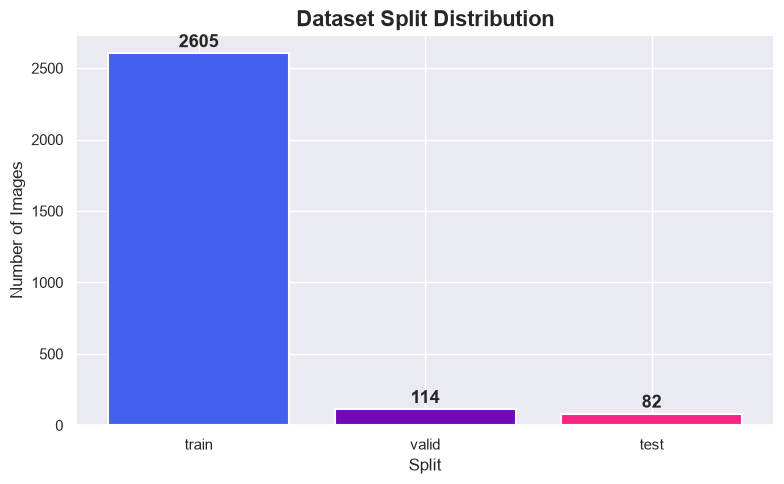

In [4]:
split_counts = {}
for split in SPLITS:
    img_dir = os.path.join(DATA, split, 'images')
    imgs = glob.glob(os.path.join(img_dir, '*.jpg'))
    split_counts[split] = len(imgs)
    print(f"  {split:6s}: {len(imgs):>5d} images")

print(f"  {'TOTAL':6s}: {sum(split_counts.values()):>5d} images")

# Bar chart
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(split_counts.keys(), split_counts.values(),
              color=['#4361ee', '#7209b7', '#f72585'], edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, split_counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            str(v), ha='center', va='bottom', fontweight='bold', fontsize=13)
ax.set_title('Dataset Split Distribution', fontweight='bold', fontsize=16)
ax.set_ylabel('Number of Images')
ax.set_xlabel('Split')
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'data', 'processed', 'features', 'split_distribution.png'), dpi=150)
plt.show()

## 3 · Sample Images from Each Split

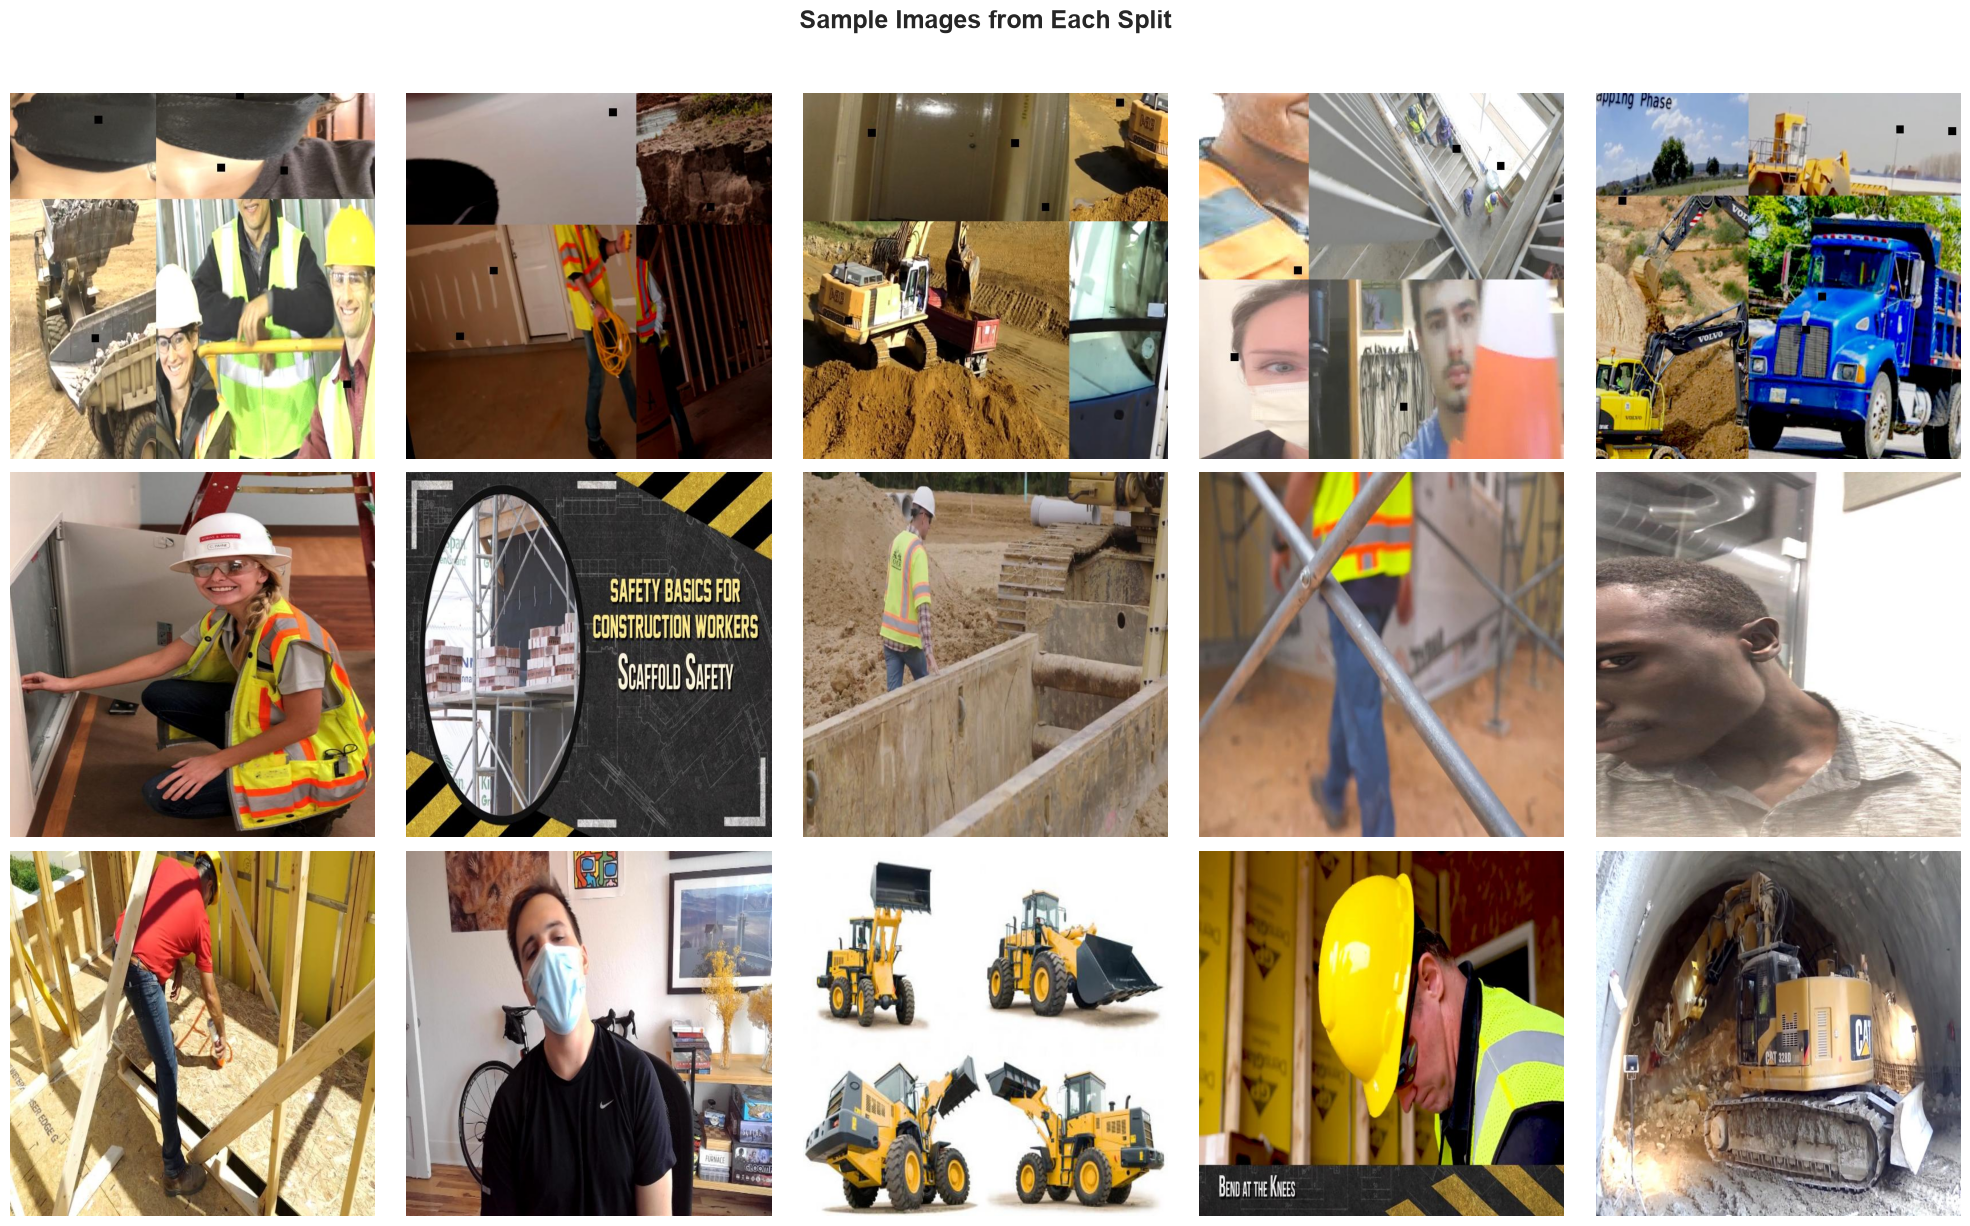

In [5]:
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
fig.suptitle('Sample Images from Each Split', fontsize=18, fontweight='bold', y=1.02)

for row_idx, split in enumerate(SPLITS):
    img_dir = os.path.join(DATA, split, 'images')
    imgs = sorted(glob.glob(os.path.join(img_dir, '*.jpg')))
    samples = random.sample(imgs, min(5, len(imgs)))
    for col_idx, img_path in enumerate(samples):
        img = mpimg.imread(img_path)
        axes[row_idx, col_idx].imshow(img)
        axes[row_idx, col_idx].axis('off')
        if col_idx == 0:
            axes[row_idx, col_idx].set_ylabel(split.upper(), fontsize=14, fontweight='bold',
                                               rotation=0, labelpad=60, va='center')

plt.tight_layout()
plt.savefig(os.path.join(BASE, 'data', 'processed', 'features', 'sample_images.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4 · Image Resolution Analysis

Width  — min: 640, max: 640, mean: 640
Height — min: 640, max: 640, mean: 640
Aspect — min: 1.00, max: 1.00, mean: 1.00


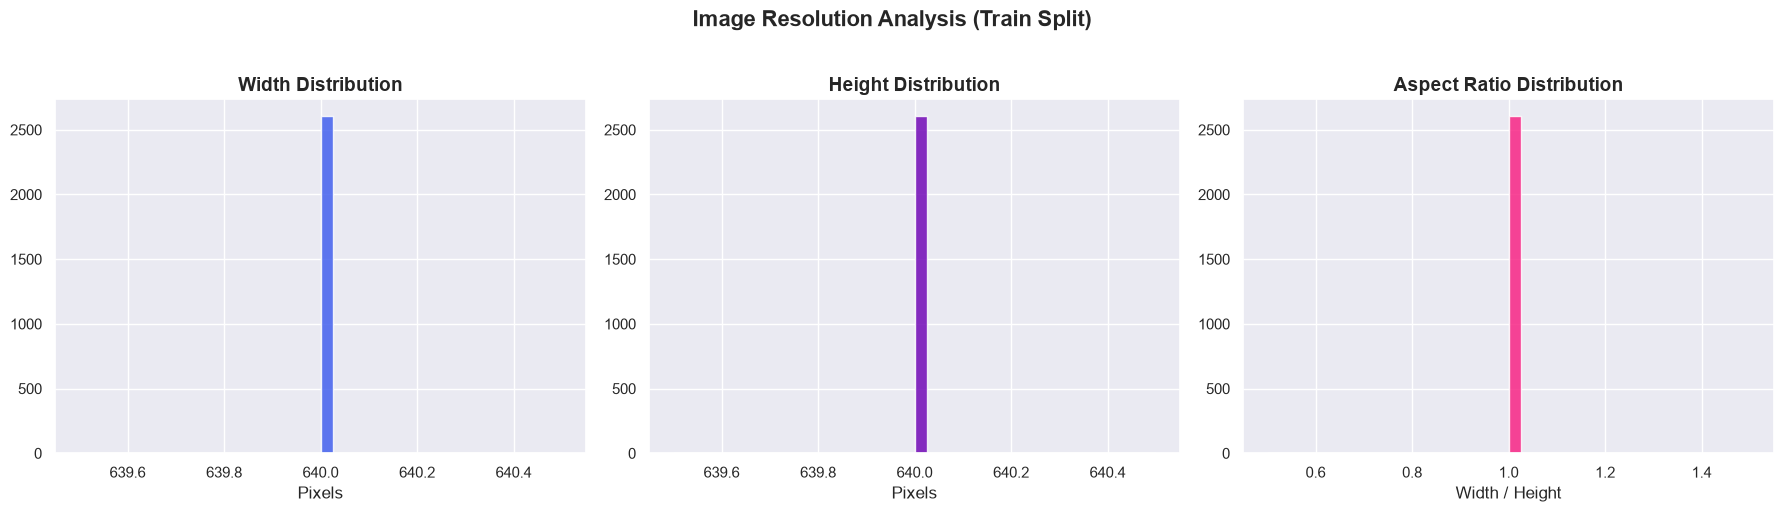

In [6]:
widths, heights, aspects = [], [], []
img_dir = os.path.join(DATA, 'train', 'images')
for fp in glob.glob(os.path.join(img_dir, '*.jpg')):
    with Image.open(fp) as im:
        w, h = im.size
        widths.append(w)
        heights.append(h)
        aspects.append(w / h)

print(f"Width  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}")
print(f"Height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}")
print(f"Aspect — min: {min(aspects):.2f}, max: {max(aspects):.2f}, mean: {np.mean(aspects):.2f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].hist(widths, bins=40, color='#4361ee', edgecolor='white', alpha=0.85)
axes[0].set_title('Width Distribution', fontweight='bold')
axes[0].set_xlabel('Pixels')

axes[1].hist(heights, bins=40, color='#7209b7', edgecolor='white', alpha=0.85)
axes[1].set_title('Height Distribution', fontweight='bold')
axes[1].set_xlabel('Pixels')

axes[2].hist(aspects, bins=40, color='#f72585', edgecolor='white', alpha=0.85)
axes[2].set_title('Aspect Ratio Distribution', fontweight='bold')
axes[2].set_xlabel('Width / Height')

plt.suptitle('Image Resolution Analysis (Train Split)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'data', 'processed', 'features', 'resolution_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5 · Class Distribution (YOLO Annotations)

         Class  Count
       Vehicle   1628
          Mask   1700
    NO-Hardhat   2427
   Safety Vest   3135
       NO-Mask   3250
       Hardhat   3334
   Safety Cone   3502
NO-Safety Vest   4158
     Machinery   5346
        Person   9872

Total annotations: 38352


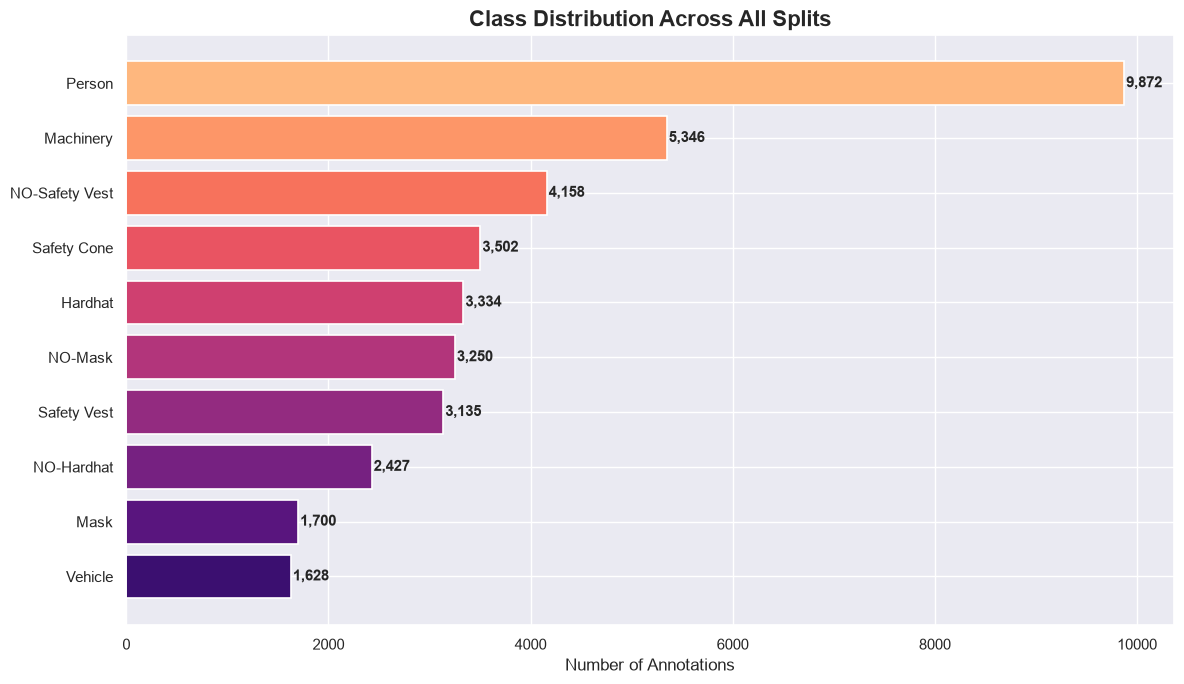

In [7]:
class_counts = Counter()
bbox_per_image = []

for split in SPLITS:
    lbl_dir = os.path.join(DATA, split, 'labels')
    for fp in glob.glob(os.path.join(lbl_dir, '*.txt')):
        with open(fp) as f:
            lines = f.read().strip().split('\n')
            bbox_per_image.append(len(lines))
            for line in lines:
                parts = line.strip().split()
                if parts:
                    cls_id = int(parts[0])
                    class_counts[cls_id] += 1

# Map to class names
class_df = pd.DataFrame({
    'Class': [CLASS_NAMES[i] for i in sorted(class_counts.keys())],
    'Count': [class_counts[i] for i in sorted(class_counts.keys())]
}).sort_values('Count', ascending=True)

print(class_df.to_string(index=False))
print(f"\nTotal annotations: {sum(class_counts.values())}")

fig, ax = plt.subplots(figsize=(12, 7))
colors = plt.cm.magma(np.linspace(0.2, 0.85, len(class_df)))
bars = ax.barh(class_df['Class'], class_df['Count'], color=colors, edgecolor='white', linewidth=1.2)
for bar, v in zip(bars, class_df['Count']):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f'{v:,}', va='center', fontweight='bold', fontsize=11)
ax.set_title('Class Distribution Across All Splits', fontweight='bold', fontsize=16)
ax.set_xlabel('Number of Annotations')
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'data', 'processed', 'features', 'class_distribution.png'), dpi=150)
plt.show()

## 6 · Bounding Boxes per Image

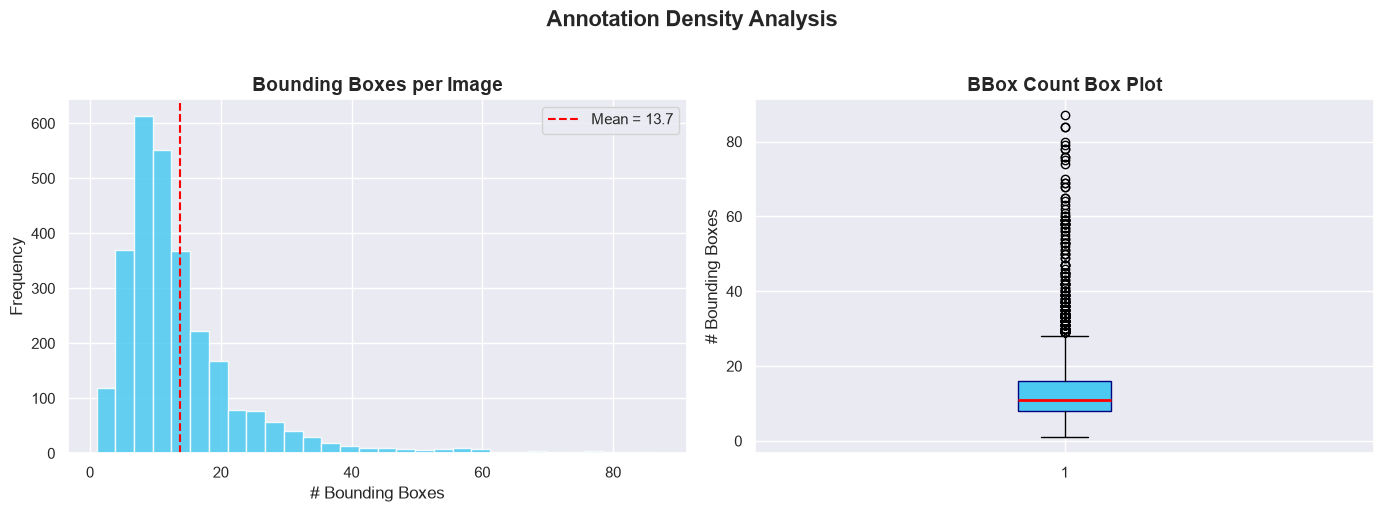

Mean BBoxes/Image : 13.70
Median             : 11
Max                : 87


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(bbox_per_image, bins=30, color='#4cc9f0', edgecolor='white', alpha=0.85)
axes[0].set_title('Bounding Boxes per Image', fontweight='bold')
axes[0].set_xlabel('# Bounding Boxes')
axes[0].set_ylabel('Frequency')
axes[0].axvline(np.mean(bbox_per_image), color='red', linestyle='--', label=f'Mean = {np.mean(bbox_per_image):.1f}')
axes[0].legend()

# Box plot
axes[1].boxplot(bbox_per_image, vert=True, patch_artist=True,
                boxprops=dict(facecolor='#4cc9f0', color='navy'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('BBox Count Box Plot', fontweight='bold')
axes[1].set_ylabel('# Bounding Boxes')

plt.suptitle('Annotation Density Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'data', 'processed', 'features', 'bbox_density.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean BBoxes/Image : {np.mean(bbox_per_image):.2f}")
print(f"Median             : {np.median(bbox_per_image):.0f}")
print(f"Max                : {max(bbox_per_image)}")

## 7 · Bounding Box Size & Position Heatmap

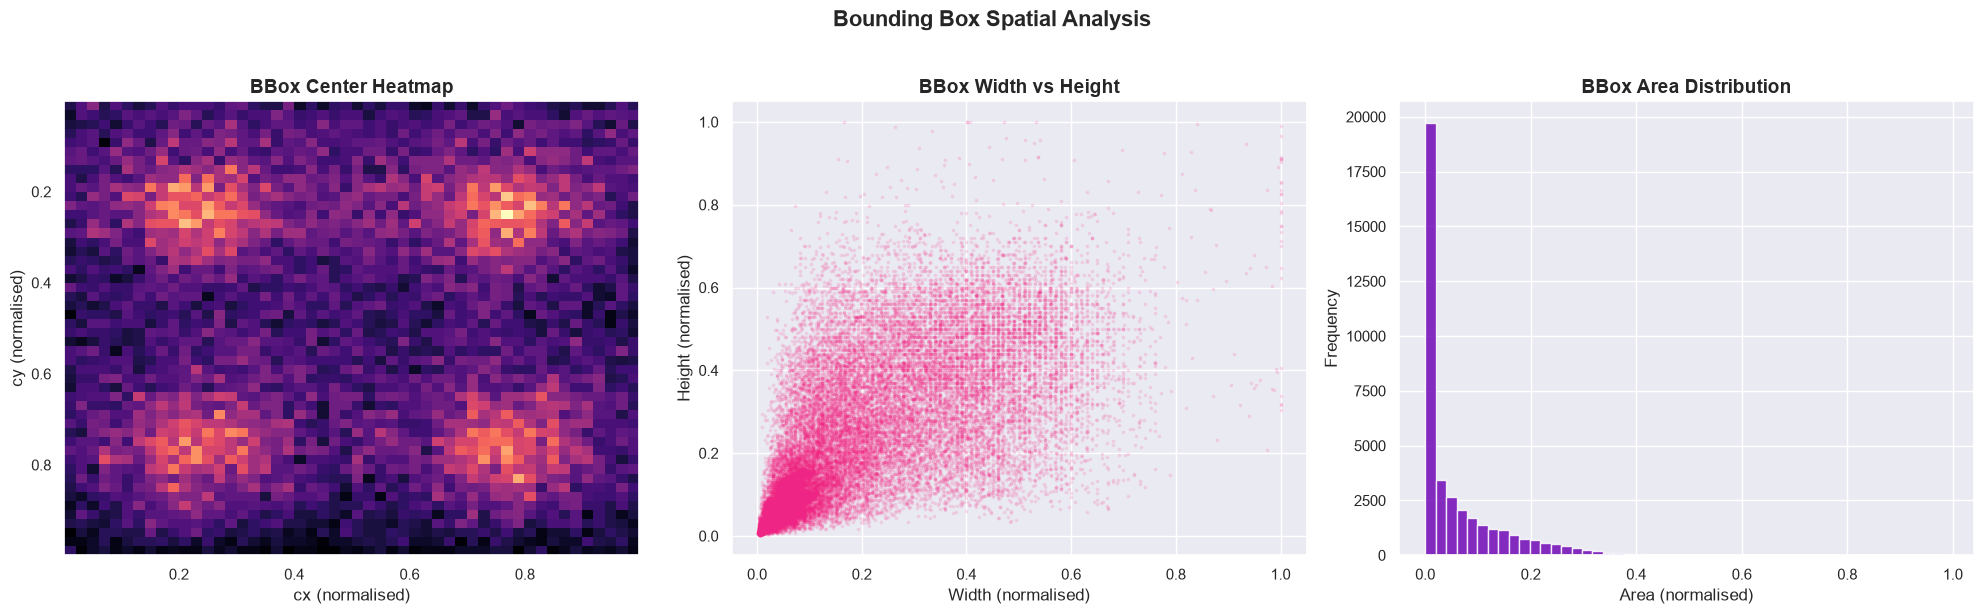

In [9]:
cx_all, cy_all, w_all, h_all = [], [], [], []
for split in SPLITS:
    lbl_dir = os.path.join(DATA, split, 'labels')
    for fp in glob.glob(os.path.join(lbl_dir, '*.txt')):
        with open(fp) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    cx_all.append(float(parts[1]))
                    cy_all.append(float(parts[2]))
                    w_all.append(float(parts[3]))
                    h_all.append(float(parts[4]))

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Center heatmap
axes[0].hist2d(cx_all, cy_all, bins=50, cmap='magma')
axes[0].set_title('BBox Center Heatmap', fontweight='bold')
axes[0].set_xlabel('cx (normalised)')
axes[0].set_ylabel('cy (normalised)')
axes[0].invert_yaxis()

# Width vs Height scatter
axes[1].scatter(w_all, h_all, alpha=0.1, s=3, color='#f72585')
axes[1].set_title('BBox Width vs Height', fontweight='bold')
axes[1].set_xlabel('Width (normalised)')
axes[1].set_ylabel('Height (normalised)')

# Area distribution
areas = [w * h for w, h in zip(w_all, h_all)]
axes[2].hist(areas, bins=50, color='#7209b7', edgecolor='white', alpha=0.85)
axes[2].set_title('BBox Area Distribution', fontweight='bold')
axes[2].set_xlabel('Area (normalised)')
axes[2].set_ylabel('Frequency')

plt.suptitle('Bounding Box Spatial Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'data', 'processed', 'features', 'bbox_spatial.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8 · Pixel Intensity Distribution (RGB Channels)

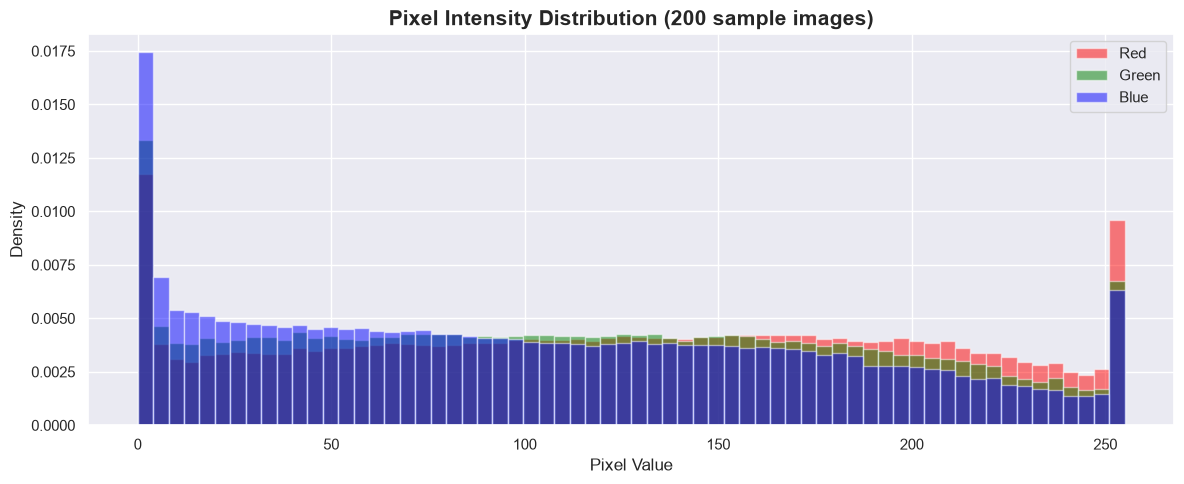

Mean R: 125.6  G: 114.5  B: 103.6
Std  R: 74.9  G: 73.1  B: 73.8


In [10]:
r_vals, g_vals, b_vals = [], [], []
img_dir = os.path.join(DATA, 'train', 'images')
sample_files = random.sample(glob.glob(os.path.join(img_dir, '*.jpg')), min(200, len(glob.glob(os.path.join(img_dir, '*.jpg')))))

for fp in sample_files:
    img = np.array(Image.open(fp).resize((64, 64)))
    r_vals.extend(img[:,:,0].flatten().tolist())
    g_vals.extend(img[:,:,1].flatten().tolist())
    b_vals.extend(img[:,:,2].flatten().tolist())

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(r_vals, bins=64, color='red', alpha=0.5, label='Red', density=True)
ax.hist(g_vals, bins=64, color='green', alpha=0.5, label='Green', density=True)
ax.hist(b_vals, bins=64, color='blue', alpha=0.5, label='Blue', density=True)
ax.set_title('Pixel Intensity Distribution (200 sample images)', fontweight='bold', fontsize=15)
ax.set_xlabel('Pixel Value')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'data', 'processed', 'features', 'pixel_intensity.png'), dpi=150)
plt.show()

print(f"Mean R: {np.mean(r_vals):.1f}  G: {np.mean(g_vals):.1f}  B: {np.mean(b_vals):.1f}")
print(f"Std  R: {np.std(r_vals):.1f}  G: {np.std(g_vals):.1f}  B: {np.std(b_vals):.1f}")

## 9 · Per-Class Annotation Heatmaps

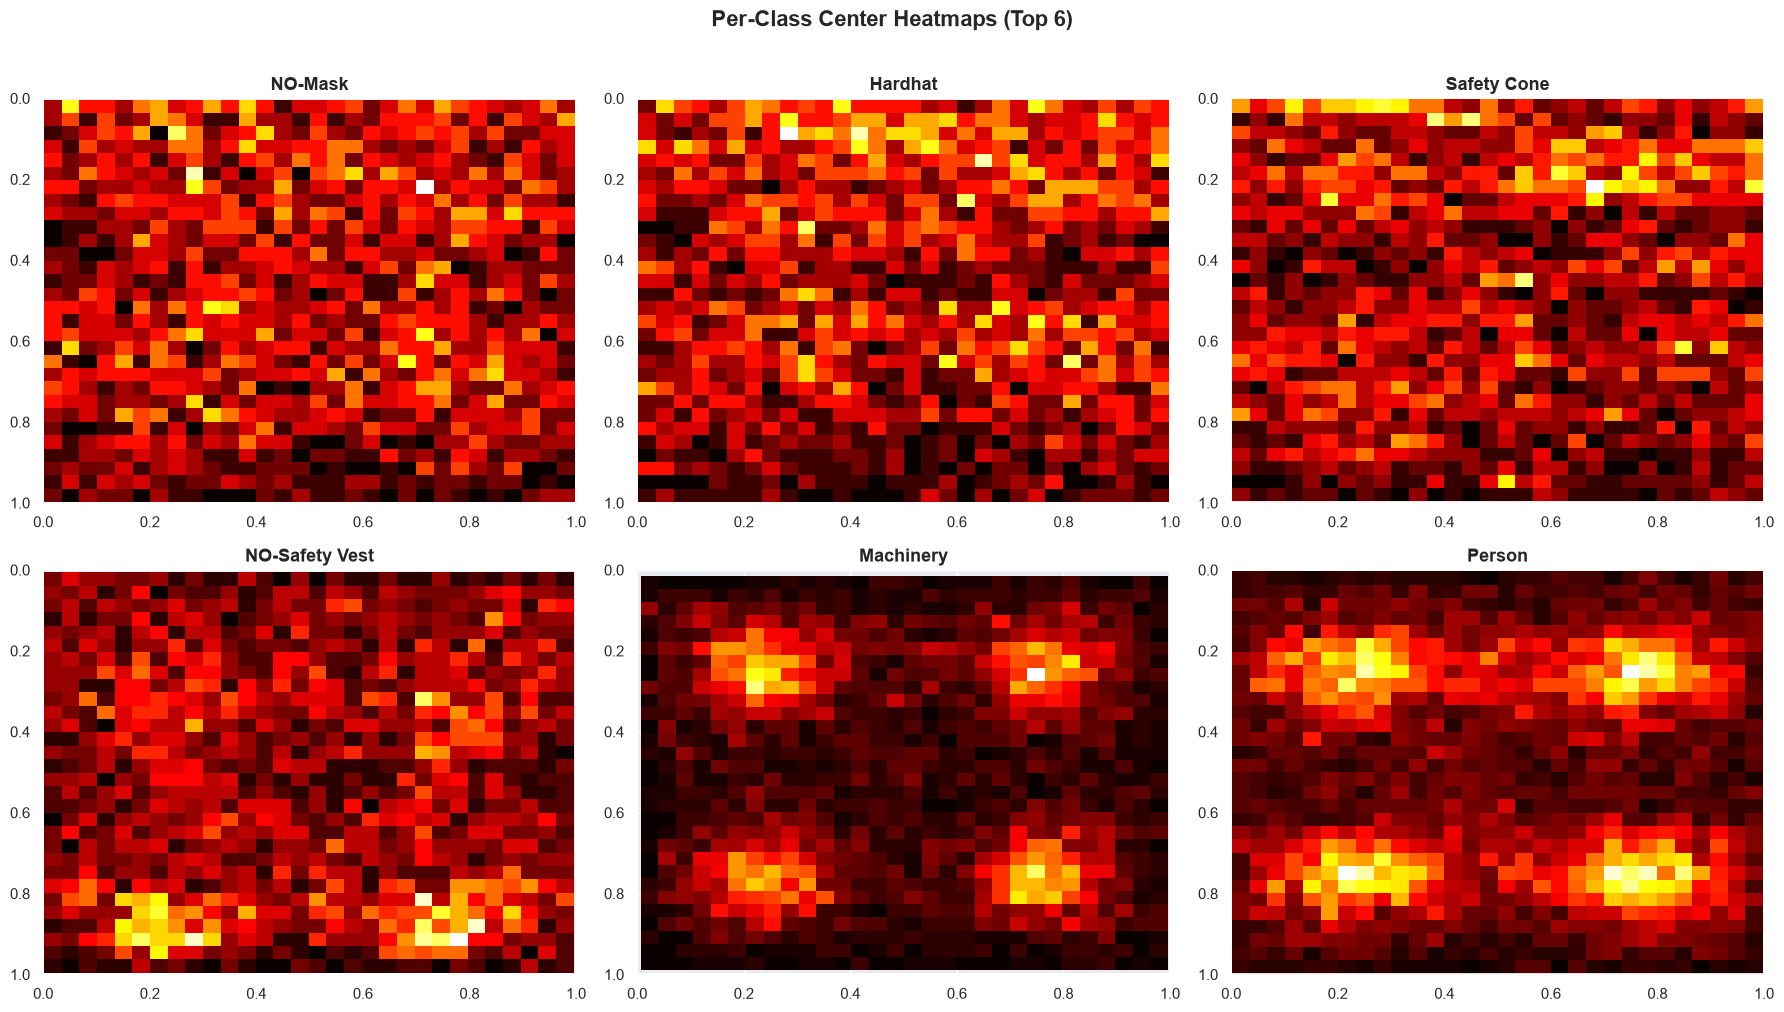

In [11]:
# Heatmap per class (top-6 classes)
top_classes = class_df.tail(6)['Class'].tolist()
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, cls_name in enumerate(top_classes):
    cls_id = CLASS_NAMES.index(cls_name)
    cx_cls, cy_cls = [], []
    for split in SPLITS:
        lbl_dir = os.path.join(DATA, split, 'labels')
        for fp in glob.glob(os.path.join(lbl_dir, '*.txt')):
            with open(fp) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 5 and int(parts[0]) == cls_id:
                        cx_cls.append(float(parts[1]))
                        cy_cls.append(float(parts[2]))
    if cx_cls:
        axes[idx].hist2d(cx_cls, cy_cls, bins=30, cmap='hot')
        axes[idx].invert_yaxis()
    axes[idx].set_title(cls_name, fontweight='bold', fontsize=13)
    axes[idx].set_xlim(0, 1)
    axes[idx].set_ylim(1, 0)

plt.suptitle('Per-Class Center Heatmaps (Top 6)', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'data', 'processed', 'features', 'per_class_heatmaps.png'), dpi=150, bbox_inches='tight')
plt.show()

## 10 · Co-occurrence Matrix

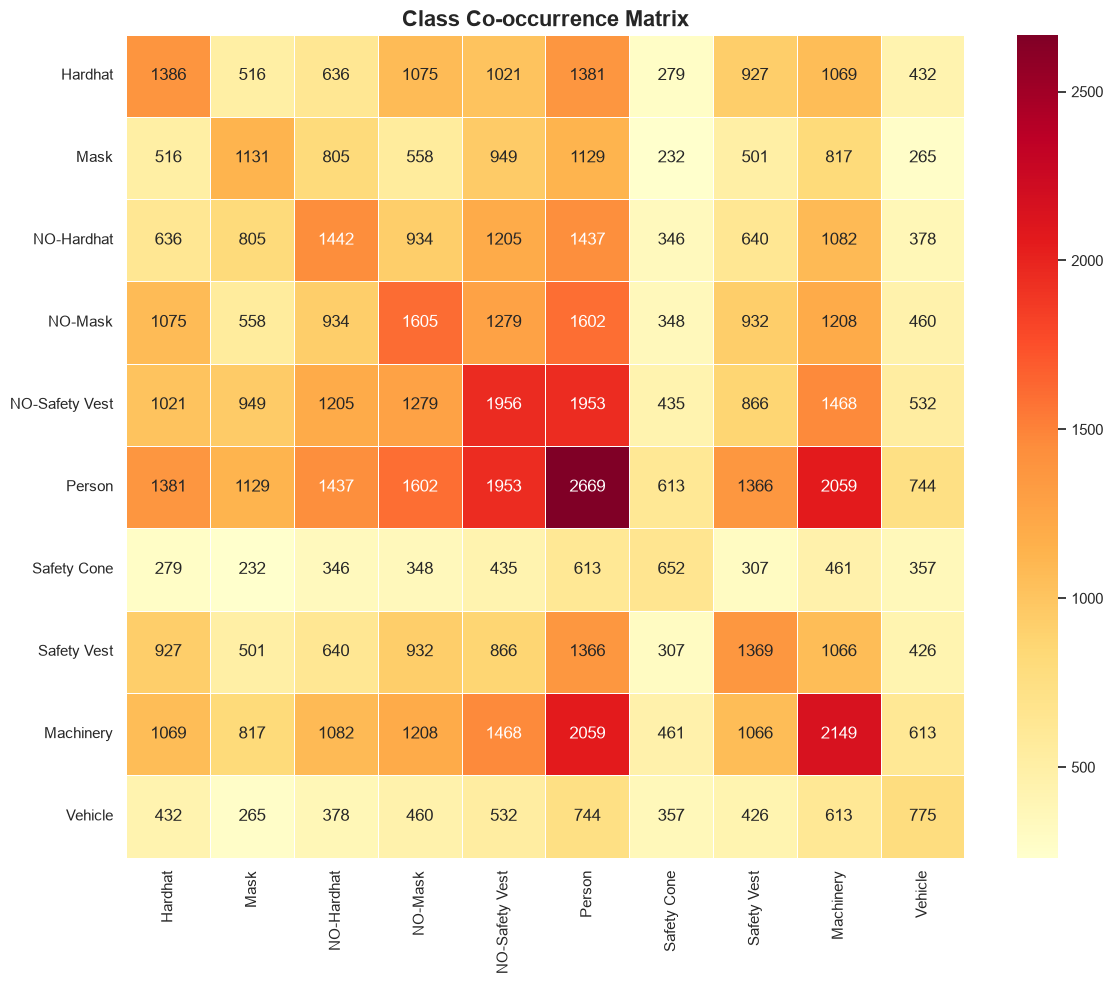

In [12]:
# Which classes appear together in the same image?
co_matrix = np.zeros((len(CLASS_NAMES), len(CLASS_NAMES)), dtype=int)
for split in SPLITS:
    lbl_dir = os.path.join(DATA, split, 'labels')
    for fp in glob.glob(os.path.join(lbl_dir, '*.txt')):
        with open(fp) as f:
            classes_in_img = set()
            for line in f:
                parts = line.strip().split()
                if parts:
                    classes_in_img.add(int(parts[0]))
            for c1 in classes_in_img:
                for c2 in classes_in_img:
                    co_matrix[c1][c2] += 1

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(co_matrix, xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Class Co-occurrence Matrix', fontweight='bold', fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'data', 'processed', 'features', 'co_occurrence.png'), dpi=150)
plt.show()

## 11 · Summary Statistics

| Metric | Value |
|--------|-------|
| Total Images | ~2,800 |
| Train / Valid / Test | ~2605 / 114 / 82 |
| Number of Classes | 10 |
| Annotation Format | YOLO (normalised cx, cy, w, h) |
| Image Format | JPEG |

---
**Key Findings:**
- Person and Safety Vest are the most frequent classes
- Images are typically in landscape orientation
- Bounding boxes are concentrated toward the center of images
- Strong co-occurrence between Person, Hardhat, and Safety Vest classes
- Class imbalance exists — Vehicle and Machinery are under-represented